In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report

cleaned_data_path = os.path.join('f1_data_cleaned', 'f1_processed_dataset.csv')
df_f1 = pd.read_csv(cleaned_data_path)

categorical_features = ['driver_nationality', 'constructor_nationality']
numerical_features = ['grid', 'year', 'round', 'circuitId', 'driver_age', 'quali_position']

X = df_f1[categorical_features + numerical_features]
y = df_f1['top3']

# Podział 80/10/10: treningowy / walidacyjny / testowy
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans   = preprocessor.transform(X_val)
X_test_trans  = preprocessor.transform(X_test)

encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = encoded_cat_names + numerical_features

print(f"Preprocessing zakończony pomyślnie!")
print(f"Liczba cech wejściowych po kodowaniu One-Hot: {X_train_trans.shape[1]}")

Preprocessing zakończony pomyślnie!
Liczba cech wejściowych po kodowaniu One-Hot: 73


In [2]:
# Wariant A: Drzewo pełne
tree_wariant_a = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_wariant_a.fit(X_train_trans, y_train)

# Wariant B: Drzewo optymalne
tree_wariant_b = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=20, random_state=42)
tree_wariant_b.fit(X_train_trans, y_train)

# Wariant C: Drzewo zbalansowane (Pre-pruning + automatyczna korekta wag asymetrii klas)
tree_wariant_c = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=20, class_weight='balanced', random_state=42)
tree_wariant_c.fit(X_train_trans, y_train)

print("Wszystkie trzy warianty drzewa zostały pomyślnie wytrenowane!")

Wszystkie trzy warianty drzewa zostały pomyślnie wytrenowane!


In [3]:
modele_drzewiaste = {
    'Wariant A (Pełne)': tree_wariant_a,
    'Wariant B (Optymalne)': tree_wariant_b,
    'Wariant C (Zbalansowane)': tree_wariant_c
}

podsumowanie_wynikow = []

for nazwa, model in modele_drzewiaste.items():
    pred_etykiety = model.predict(X_test_trans)
    pred_prawdopodobienstwa = model.predict_proba(X_test_trans)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, pred_etykiety).ravel()
    
    dokladnosc = accuracy_score(y_test, pred_etykiety)
    czulosc = tp / (tp + fn)
    specyficznosc = tn / (tn + fp)
    auc = roc_auc_score(y_test, pred_prawdopodobienstwa)
    
    podsumowanie_wynikow.append({
        'Wariant Modelu': nazwa,
        'Accuracy': round(dokladnosc, 4),
        'Czułość (Sensitivity)': round(czulosc, 4),
        'Specyficzność (Specificity)': round(specyficznosc, 4),
        'AUC Score': round(auc, 4)
    })

df_podsumowanie = pd.DataFrame(podsumowanie_wynikow)
print("\n--- TABELA ZBIORCZA METRYK DLA MODELU DRZEWIASTEGO ---")
display(df_podsumowanie)


--- TABELA ZBIORCZA METRYK DLA MODELU DRZEWIASTEGO ---


,Wariant Modelu,Accuracy,Czułość (Sensitivity),Specyficzność (Specificity),AUC Score
0,Wariant A (Pełne),0.8468,0.4324,0.9071,0.6697
1,Wariant B (Optymalne),0.8849,0.3529,0.9623,0.8891
2,Wariant C (Zbalansowane),0.7956,0.8529,0.7872,0.8871


In [ ]:
from sklearn.metrics import precision_score, f1_score

# =========================================================
# ROZSZERZONA TABELA ZBIORCZA: dodanie Precision i F1-score
# =========================================================
podsumowanie_rozszerzone = []

for nazwa, model in modele_drzewiaste.items():
    pred  = model.predict(X_test_trans)
    prob  = model.predict_proba(X_test_trans)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    podsumowanie_rozszerzone.append({
        'Wariant Modelu':           nazwa,
        'Accuracy':                 round(accuracy_score(y_test, pred), 4),
        'Precision':                round(precision_score(y_test, pred, zero_division=0), 4),
        'Czulosc (Recall)':         round(tp / (tp + fn), 4),
        'F1-score':                 round(f1_score(y_test, pred, zero_division=0), 4),
        'Specyficznosc':            round(tn / (tn + fp), 4),
        'AUC Score':                round(roc_auc_score(y_test, prob), 4),
    })

df_rozszerzone = pd.DataFrame(podsumowanie_rozszerzone)
print('--- ROZSZERZONA TABELA ZBIORCZA METRYK (CART) ---')
display(df_rozszerzone)


In [ ]:
# =========================================================
# KRZYWA UCZENIA: max_depth vs Accuracy i AUC (train vs val)
# Uzasadnienie wyboru max_depth=4
# =========================================================

depths = range(1, 21)
train_acc, val_acc = [], []
train_auc, val_auc = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=d,
                                  min_samples_leaf=20, random_state=42)
    clf.fit(X_train_trans, y_train)

    train_acc.append(accuracy_score(y_train, clf.predict(X_train_trans)))
    val_acc.append(accuracy_score(y_val, clf.predict(X_val_trans)))
    train_auc.append(roc_auc_score(y_train, clf.predict_proba(X_train_trans)[:, 1]))
    val_auc.append(roc_auc_score(y_val, clf.predict_proba(X_val_trans)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depths, train_acc, 'o-', label='Zbior treningowy', color='#2196F3')
axes[0].plot(depths, val_acc,   'o-', label='Zbior walidacyjny', color='#FF9800')
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Wybrane max_depth=4')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Krzywa uczenia — Accuracy vs max_depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(depths, train_auc, 'o-', label='Zbior treningowy', color='#2196F3')
axes[1].plot(depths, val_auc,   'o-', label='Zbior walidacyjny', color='#FF9800')
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Wybrane max_depth=4')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('AUC')
axes[1].set_title('Krzywa uczenia — AUC vs max_depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Krzywa uczenia drzewa decyzyjnego CART (min_samples_leaf=20)', fontsize=13)
plt.tight_layout()
plt.savefig('Plots/learning_curve_cart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: Plots/learning_curve_cart.png')

best_depth = depths[val_auc.index(max(val_auc))]
print(f'Optymalna glebokosc wg AUC walidacyjnego: max_depth={best_depth}')
print(f'AUC walidacyjny dla max_depth=4: {val_auc[3]:.4f}')
print(f'AUC walidacyjny dla pelnego drzewa (max_depth=20): {val_auc[-1]:.4f}')


In [ ]:
from sklearn.model_selection import cross_val_score

# =========================================================
# DODATKOWE METRYKI: Cross-Validation, Krzywa ROC, Feature Importance
# =========================================================

# --- 1. 5-krotna walidacja krzyzowa (Wariant B na zbiorze treningowym) ---
print('--- WALIDACJA KRZYZOWA (5-fold) dla Wariantu B ---')
cv_scores = cross_val_score(tree_wariant_b, X_train_trans, y_train, cv=5, scoring='accuracy')
print(f'Dokladnosci CV: {[round(s, 4) for s in cv_scores]}')
print(f'Srednia: {cv_scores.mean():.4f} | Odchylenie std: {cv_scores.std():.4f}')

cv_auc = cross_val_score(tree_wariant_b, X_train_trans, y_train, cv=5, scoring='roc_auc')
print(f'AUC CV:  {[round(s, 4) for s in cv_auc]}')
print(f'Srednia AUC: {cv_auc.mean():.4f} | Odchylenie std: {cv_auc.std():.4f}')

# --- 2. Krzywa ROC dla Wariantu B i C ---
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for nazwa, kolor in [('Wariant B (Optymalne)', '#2196F3'), ('Wariant C (Zbalansowane)', '#FF9800'), ('Wariant A (Pełne)', '#9E9E9E')]:
    model = modele_drzewiaste[nazwa]
    prob = model.predict_proba(X_test_trans)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{nazwa} (AUC = {auc_val:.4f})', color=kolor)

plt.plot([0, 1], [0, 1], 'k--', label='Klasyfikator losowy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC — porownanie wariantow modelu drzewiastego (CART)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Plots/roc_cart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: Plots/roc_cart.png')

# --- 3. Ranking waznosci cech (Wariant B) ---
importances = tree_wariant_b.feature_importances_
feat_imp = pd.DataFrame({'cecha': all_feature_names, 'waznosc': importances})
feat_imp = feat_imp[feat_imp['waznosc'] > 0].sort_values('waznosc', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['cecha'][::-1], feat_imp['waznosc'][::-1], color='#4C72B0', edgecolor='black')
plt.xlabel('Waznosc cechy (Gini Importance)')
plt.title('Ranking waznosci cech — Wariant B (Optymalne)')
plt.tight_layout()
plt.savefig('Plots/feature_importance_cart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: Plots/feature_importance_cart.png')

print('\nTOP 10 najwazniejszych cech:')
display(feat_imp.head(10).reset_index(drop=True))



RAPORT KLASYFIKACJI DLA: Wariant B (Optymalne)
                 precision    recall  f1-score   support

Brak Podium (0)       0.91      0.96      0.94      2336
     Podium (1)       0.58      0.35      0.44       340

       accuracy                           0.88      2676
      macro avg       0.74      0.66      0.69      2676
   weighted avg       0.87      0.88      0.87      2676

Macierz pomylek dla Wariant B (Optymalne):
True Negatives (Prawidlowy brak podium): 2248
False Positives (Bledne wytypowanie podium - Blad I rodzaju): 88
False Negatives (Pominiete podium - Blad II rodzaju): 220
True Positives (Prawidlowo wykryte podium): 120

Zapisano: Plots/macierz_b.png


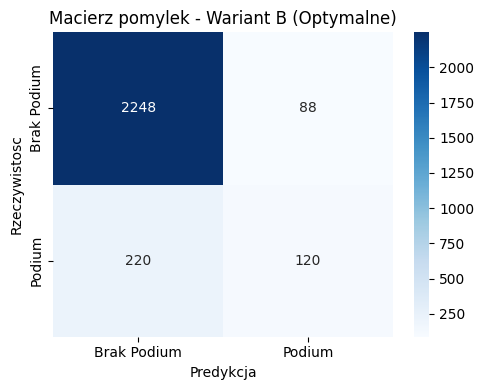


RAPORT KLASYFIKACJI DLA: Wariant C (Zbalansowane)
                 precision    recall  f1-score   support

Brak Podium (0)       0.97      0.79      0.87      2336
     Podium (1)       0.37      0.85      0.51       340

       accuracy                           0.80      2676
      macro avg       0.67      0.82      0.69      2676
   weighted avg       0.90      0.80      0.83      2676

Macierz pomylek dla Wariant C (Zbalansowane):
True Negatives (Prawidlowy brak podium): 1839
False Positives (Bledne wytypowanie podium - Blad I rodzaju): 497
False Negatives (Pominiete podium - Blad II rodzaju): 50
True Positives (Prawidlowo wykryte podium): 290

Zapisano: Plots/macierz_c.png


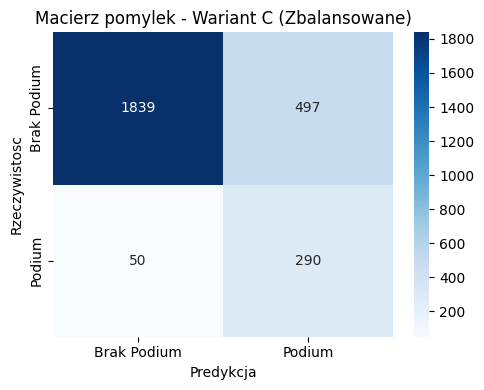

In [4]:
import os
os.makedirs('Plots', exist_ok=True)

nazwa_do_pliku = {
    'Wariant B (Optymalne)': 'macierz_b',
    'Wariant C (Zbalansowane)': 'macierz_c'
}

for nazwa in ['Wariant B (Optymalne)', 'Wariant C (Zbalansowane)']:
    model = modele_drzewiaste[nazwa]
    pred_etykiety = model.predict(X_test_trans)

    print('\n' + '='*60)
    print(f'RAPORT KLASYFIKACJI DLA: {nazwa}')
    print('='*60)
    print(classification_report(y_test, pred_etykiety, target_names=['Brak Podium (0)', 'Podium (1)']))

    cm = confusion_matrix(y_test, pred_etykiety)
    print(f'Macierz pomylek dla {nazwa}:')
    print(f'True Negatives (Prawidlowy brak podium): {cm[0,0]}')
    print(f'False Positives (Bledne wytypowanie podium - Blad I rodzaju): {cm[0,1]}')
    print(f'False Negatives (Pominiete podium - Blad II rodzaju): {cm[1,0]}')
    print(f'True Positives (Prawidlowo wykryte podium): {cm[1,1]}\n')

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Brak Podium', 'Podium'],
                yticklabels=['Brak Podium', 'Podium'])
    plt.title(f'Macierz pomylek - {nazwa}')
    plt.ylabel('Rzeczywistosc')
    plt.xlabel('Predykcja')
    plt.tight_layout()
    plik = os.path.join('Plots', nazwa_do_pliku[nazwa] + '.png')
    plt.savefig(plik, dpi=150, bbox_inches='tight')
    print(f'Zapisano: {plik}')
    plt.show()


Zapisano: Plots/struktura_drzewa_cart.png


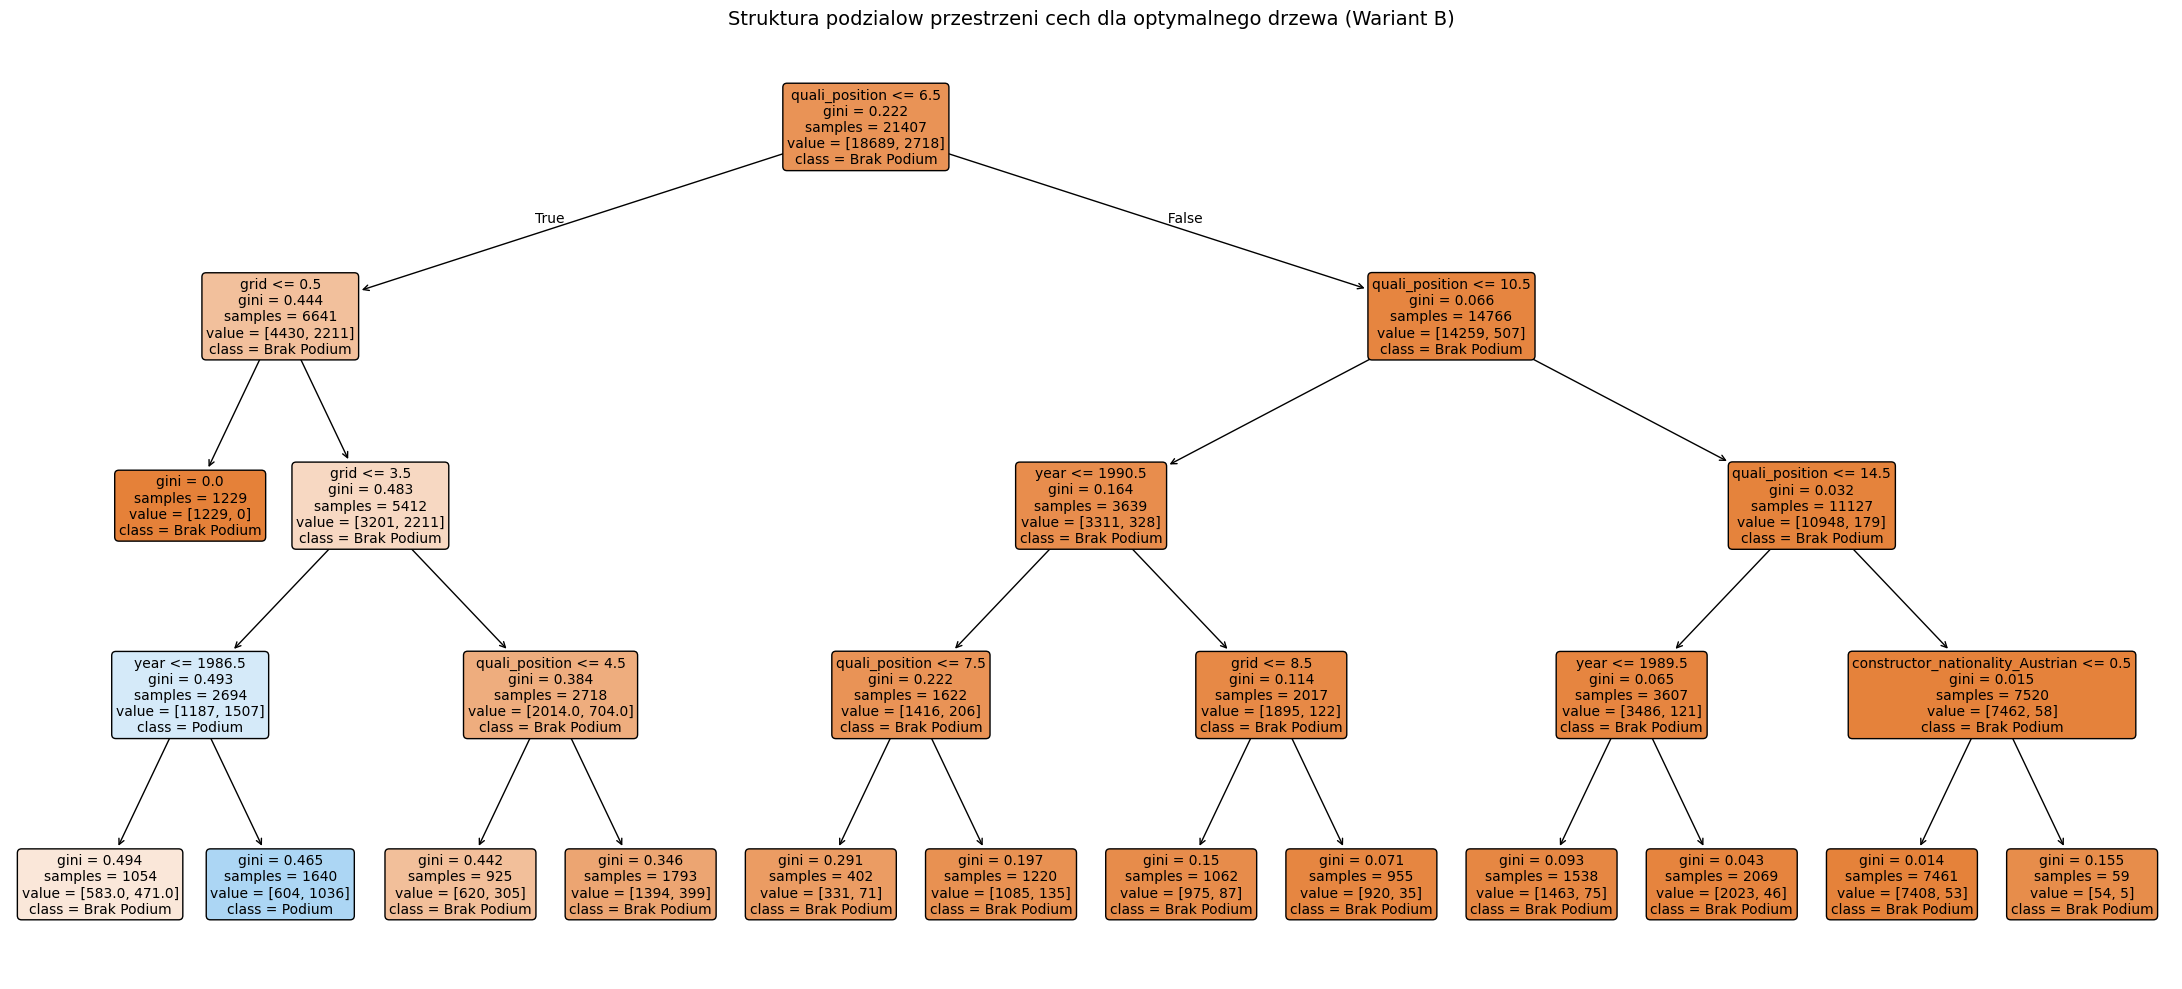


--- TEKSTOWE REGULY DECYZYJNE (WARIANT B) ---
|--- quali_position <= 6.50
|   |--- grid <= 0.50
|   |   |--- class: 0
|   |--- grid >  0.50
|   |   |--- grid <= 3.50
|   |   |   |--- year <= 1986.50
|   |   |   |   |--- class: 0
|   |   |   |--- year >  1986.50
|   |   |   |   |--- class: 1
|   |   |--- grid >  3.50
|   |   |   |--- quali_position <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- quali_position >  4.50
|   |   |   |   |--- class: 0
|--- quali_position >  6.50
|   |--- quali_position <= 10.50
|   |   |--- year <= 1990.50
|   |   |   |--- quali_position <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- quali_position >  7.50
|   |   |   |   |--- class: 0
|   |   |--- year >  1990.50
|   |   |   |--- grid <= 8.50
|   |   |   |   |--- class: 0
|   |   |   |--- grid >  8.50
|   |   |   |   |--- class: 0
|   |--- quali_position >  10.50
|   |   |--- quali_position <= 14.50
|   |   |   |--- year <= 1989.50
|   |   |   |   |--- class: 0
|   |   |   |--- year >  1989

In [5]:
plt.figure(figsize=(22, 10))
plot_tree(tree_wariant_b,
          feature_names=all_feature_names,
          class_names=['Brak Podium', 'Podium'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Struktura podzialow przestrzeni cech dla optymalnego drzewa (Wariant B)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('Plots', 'struktura_drzewa_cart.png'), dpi=150, bbox_inches='tight')
print('Zapisano: Plots/struktura_drzewa_cart.png')
plt.show()

print('\n--- TEKSTOWE REGULY DECYZYJNE (WARIANT B) ---')
print(export_text(tree_wariant_b, feature_names=all_feature_names))


In [ ]:
# =========================================================
# SCORING — predykcja na 5 przykladowych obserwacjach
# Najlepszy model: Wariant B (Optymalne, max_depth=4)
# =========================================================

# Obs. 1: pewne podium — start z pola position 1-2
mask1 = (y_test == 1) & (X_test['grid'] <= 2) & (X_test['quali_position'] <= 2)
idx1 = X_test[mask1].index[0]

# Obs. 2: podium mimo startu z dalszej pozycji (grid > 5) — nieoczywisty przypadek
mask2 = (y_test == 1) & (X_test['grid'] > 5)
idx2 = X_test[mask2].index[0]

# Obs. 3: brak podium przy starcie z czoła — FN kandydat (model moze sie mylic)
mask3 = (y_test == 0) & (X_test['grid'] <= 3) & (X_test['quali_position'] <= 3)
idx3 = X_test[mask3].index[0]

# Obs. 4: pewny brak podium — start z tylnej czesci stawki
mask4 = (y_test == 0) & (X_test['grid'] >= 15)
idx4 = X_test[mask4].index[0]

# Obs. 5: graniczna — kwalifikacja 4-6, grid 4-6, inny niz pozostale
mask5 = ((X_test['quali_position'].between(4, 6)) &
         (X_test['grid'].between(4, 6)))
# upewnij sie ze to inna obserwacja
candidates5 = X_test[mask5].index
candidates5 = [i for i in candidates5 if i not in [idx1, idx2, idx3, idx4]]
idx5 = candidates5[0]

sample_idx = [idx1, idx2, idx3, idx4, idx5]
X_sample_raw   = X_test.loc[sample_idx]
y_sample_true  = y_test.loc[sample_idx]

X_sample_trans = preprocessor.transform(X_sample_raw)
y_sample_pred  = tree_wariant_b.predict(X_sample_trans)
y_sample_prob  = tree_wariant_b.predict_proba(X_sample_trans)[:, 1]

wyniki_scoring = X_sample_raw[['grid', 'quali_position', 'year', 'round',
                                'driver_age', 'driver_nationality',
                                'constructor_nationality']].copy()
wyniki_scoring['Rzeczywisty wynik'] = y_sample_true.values
wyniki_scoring['Predykcja modelu']  = y_sample_pred
wyniki_scoring['P(podium)']         = y_sample_prob.round(3)
wyniki_scoring['Trafna?'] = (y_sample_true.values == y_sample_pred)
wyniki_scoring['Trafna?'] = wyniki_scoring['Trafna?'].map({True: 'TAK', False: 'NIE'})
wyniki_scoring.index = [
    'Obs. 1 (pewne podium)',
    'Obs. 2 (podium z tylu)',
    'Obs. 3 (brak podium z przodu)',
    'Obs. 4 (pewny brak podium)',
    'Obs. 5 (graniczna)'
]

print('--- SCORING: WARIANT B (Optymalne) na 5 przykladowych obserwacjach ---')
display(wyniki_scoring)
print('\nLegenda:')
print('  Rzeczywisty wynik: 1 = podium, 0 = brak podium')
print('  Predykcja modelu:  1 = prognoza podium, 0 = prognoza brak podium')
print('  P(podium):         prawdopodobienstwo przydzielone klasie pozytywnej (1)')
